In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score

import joblib


### Read data

In [ ]:
# Read features
dist_data = pd.read_csv('../data/selected_structures.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/transcriptional_data.tsv', sep='\t')

### Check data distribution

In [3]:
dist_data.head(2)

,Chromosome copy number,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,34-35,34-36,34-37,34-38,35-36,35-37,35-38,36-37,36-38,37-38
0,7,372.927607,551.823341,531.536452,528.043559,503.838268,318.499608,243.517966,461.937225,407.748697,...,355.828610,344.020348,117.341382,425.809817,210.518408,249.148550,76.197113,237.168716,225.809654,317.743607
1,8,349.160422,630.362594,289.207538,667.809853,593.666573,453.601146,334.396471,671.357580,815.738929,...,578.358021,872.294675,142.390309,632.193799,444.888750,529.982075,373.966576,798.924903,677.440034,536.192130


In [4]:
transc_data.head(2)

,Chromosome copy number,BACH1,CCT8,LTN1,N6AMT1,USP16
0,7,1,0,0,0,0
1,8,0,0,0,0,0


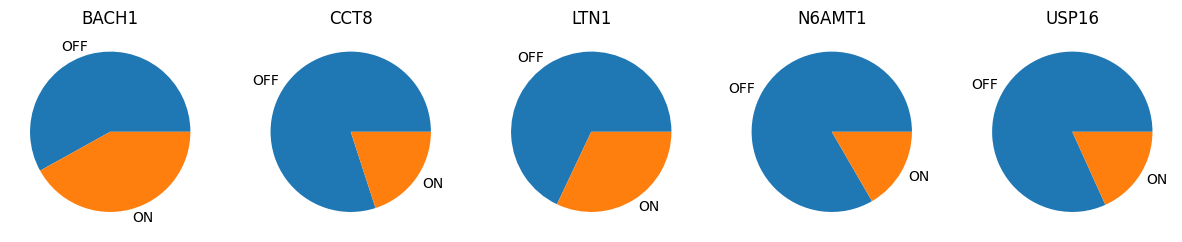

In [5]:
gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 5, figsize=(15, 3))

for i, gene in enumerate(gene_names):
    axs[i].pie(transc_data[gene].value_counts(), labels=['OFF', 'ON'])
    axs[i].set_title(f"{gene}")


### Preprocess data

##### Will use data from BACH1 gene, which is the most balaced dataset (328 OFF vs 237 ON)

In [6]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='Chromosome copy number').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

### Create model - use grid search for hyperparameter tuning

In [7]:
# Define parameter search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0, 0.5, 1], # Non-deprecated update to penalty. 0: L2, 0.5: elasticnet, 1: L1
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

In [8]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Define model
log_reg_model = LogisticRegression()

In [11]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=log_reg_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

### Fit model - using entire parameter space

In [12]:
hist = grid_search_random_forest_model.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END C=0.001, class_weight=None, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0.5, solver=saga; total time=   0.0s
[CV] END C=0.001, class_weight=None, l1_ratio=0.5, solver=liblinear; tota

/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: Conver

[CV] END C=0.01, class_weight=None, l1_ratio=0.5, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=1, solver=liblinear; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=1, solver=liblinear; total time=   

/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: Conver

[CV] END C=0.1, class_weight=None, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, l1_ratio=0, solver=saga; total time=   0.1s
[CV] END C=0.1, class_weight=balanced, l1_ratio=0, solver=liblinear; total time=   0.0s
[CV] END .C=0.01, class_weight=None, l1_ratio=0, solver=saga; total time=   0.1s
[CV] END .C=0.01, class_weight=None, l1_ratio=0, solver=saga; total time=   0.1s
[CV] END C=0.1, class_weight=balanced, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.1, class_weight=balanced, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.1, class_weight=balanced, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.1, class_weight=balanced, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END ..C=0.1, class_weight=None, l1_ratio=0, solver=saga; total time=   0.1s
[CV] END C=0.1, class_weight=balanced, l1_ratio=0.5, solver=liblinear; total time=   0.0s
[CV] END C=0.1, class_weight=None, l1_ratio=0, solver=

...

/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: Conver

[CV] END ...C=10, class_weight=None, l1_ratio=1, solver=saga; total time=   0.2s
[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=saga; total time=   0.2s
[CV] END C=1, class_weight=balanced, l1_ratio=0, solver=liblinear; total time=   0.1s
[CV] END C=10, class_weight=balanced, l1_ratio=0.5, solver=saga; total time=   0.2s
[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=saga; total time=   0.2s
[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=liblinear; total time=   0.1s
[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=liblinear; total time=   0.1s
[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=saga; total time=   0.1s


/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=saga; total time=   0.2s
[CV] END C=10, class_weight=balanced, l1_ratio=1, solver=saga; total time=   0.1s


/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~

### Save hyperparameter tuning results

In [13]:
joblib.dump(grid_search_random_forest_model, "../results/logistic_regression/gridsearch_results_logistic_regression.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/logistic_regression/gridsearch_results_logistic_regression.tsv", index=False, sep='\t')

In [14]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/logistic_regression/hyperparams.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'solver': 'saga'}


### Calculate predictions and plot metrics

In [15]:
# Select best model
best_model = grid_search_random_forest_model.best_estimator_

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

In [17]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

In [18]:
# Print classification report
print(class_report)

with open('../results/logistic_regression/classification_report.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.63      0.41      0.50        66
           1       0.44      0.66      0.53        47

    accuracy                           0.51       113
   macro avg       0.54      0.53      0.51       113
weighted avg       0.55      0.51      0.51       113



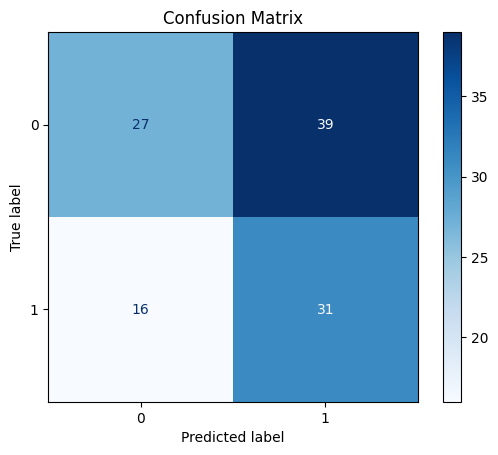

In [19]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/logistic_regression/confusion_matrix.pdf', format='pdf')

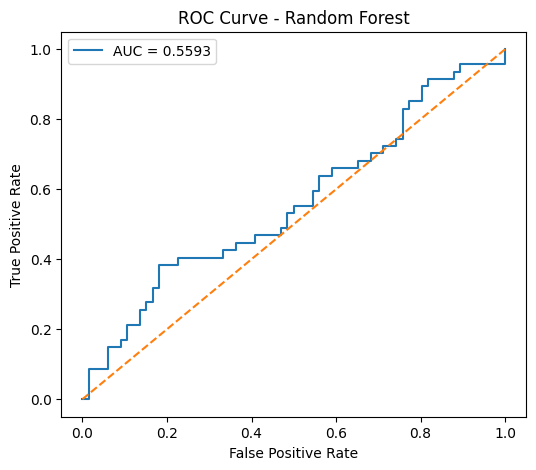

In [20]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/logistic_regression/ROC.pdf', format='pdf')

In [ ]:
# Get feture importances
n_feats = 20
coefficients = pd.Series(best_model.coef_[0], index=dataset.columns[:-1])
coefficients.sort_values(inplace=True)
coefficients_first = coefficients[:int(n_feats/2)]
coefficients_last = coefficients[-int(n_feats/2):]
coefficients = pd.concat([coefficients_first, coefficients_last])


In [ ]:
# Plot feature importances
plt.title("Feature Coefficients in Logistic Regression Churn Model")
coefficients.plot(kind='barh')

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Coefficients in logistic regression")

plt.savefig('../results/logistic_regression/coefficients.pdf', format='pdf')

## Redo analysis using best-tuned model and bigger dataset (more flexible filtering)

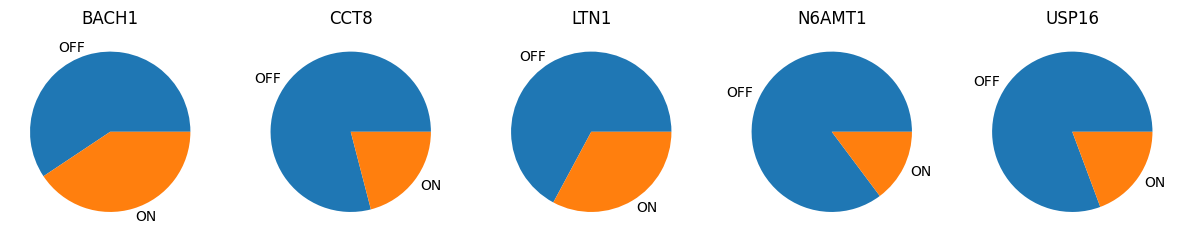

In [ ]:
# Read features
dist_data = pd.read_csv('../data/selected_structures_1000_nm_thr.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/transcriptional_data_1000_nm_thr.tsv', sep='\t')

gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 5, figsize=(15, 3))

for i, gene in enumerate(gene_names):
    axs[i].pie(transc_data[gene].value_counts(), labels=['OFF', 'ON'])
    axs[i].set_title(f"{gene}")

In [85]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='Chromosome copy number').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [86]:
# Train model
log_reg_model = LogisticRegression(C=0.1, class_weight='balanced', l1_ratio=0.5, solver='saga')

In [87]:
hist = log_reg_model.fit(X_train, y_train)

/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Calculate predictions and plot metrics

In [88]:
# Calculate predictions
y_pred = log_reg_model.predict(X_test)
y_pred_scores = log_reg_model.predict_proba(X_test)[:,1]

In [89]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

In [90]:
# Print classification report
print(class_report)

with open('../results/logistic_regression/classification_report_1000_nm_thr.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.63      0.58      0.61       379
           1       0.45      0.50      0.48       259

    accuracy                           0.55       638
   macro avg       0.54      0.54      0.54       638
weighted avg       0.56      0.55      0.55       638



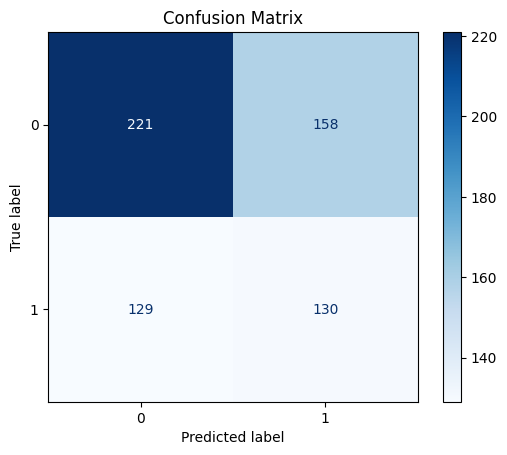

In [91]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/logistic_regression/confusion_matrix_1000_nm_thr.pdf', format='pdf')

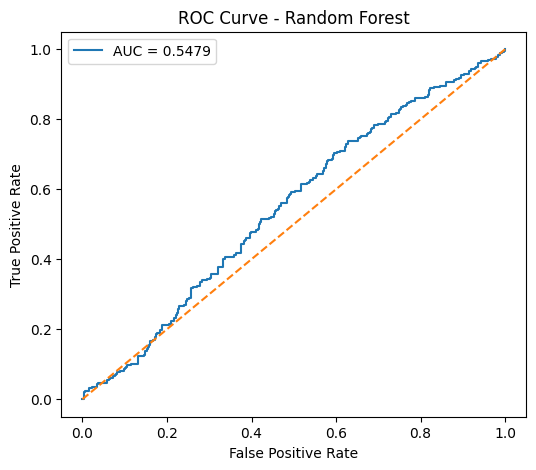

In [92]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/logistic_regression/ROC_1000_nm_thr.pdf', format='pdf')

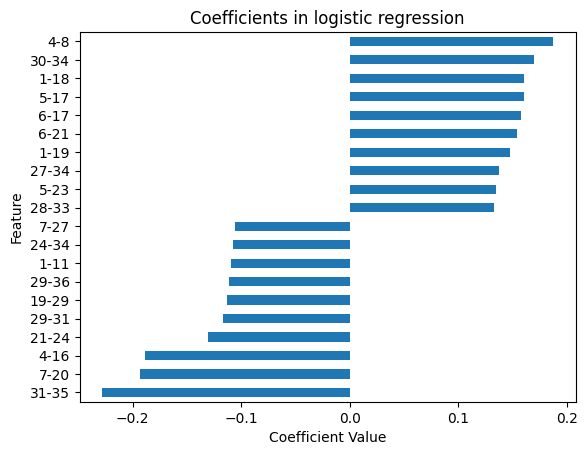

In [93]:
# Plot feature importances
plt.title("Feature Coefficients in Logistic Regression Churn Model")
coefficients.plot(kind='barh')

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Coefficients in logistic regression")

plt.savefig('../results/logistic_regression/coefficients_1000_nm_thr.pdf', format='pdf')